# MCYSD-23 Machine Learning Optimization Lecture

A Jupyter notebook demonstrating concepts of machine learning optimization.
It covers GD, AdaGrad, RMSProp, Adam, Momentum, and compares some concepts to sklearn.
It discusses learning rate and hyperparameter tuning, and provides visualizations for comparisons and understanding of convergence and behaviours.

Group Members
- John P.
- Alvaro G. G.
- Chris D.

## Hello World

In [2]:
print("Hello World!")

Hello World!


In [3]:
from main import main
main()

Hello from ml-optimization-lecture!


# Example of loss with different learning rates

Learning rate is a crucial hyperparameter in optimization algorithms. It determines the step size at each iteration while moving toward a minimum of a loss function. Choosing an appropriate learning rate can significantly affect the convergence and performance of the model.

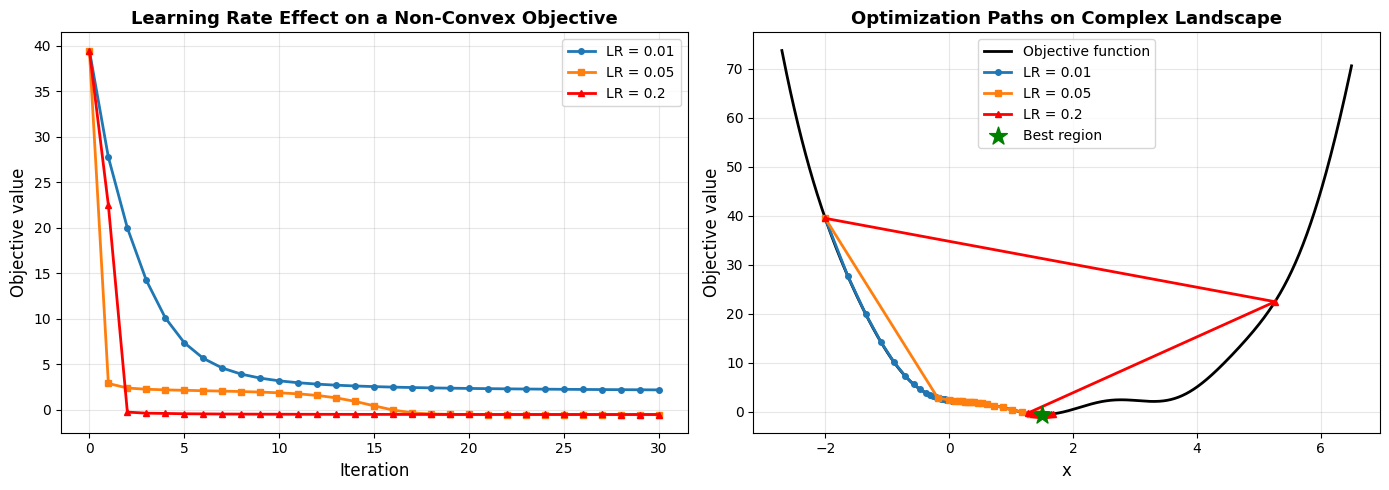

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function: f(x) = 0.15*(x - 2)^4 + 1*sin(3x) + 0.2*x^2
def loss_function(x):
    return 0.15 * (x - 2) ** 4 + 1 * np.sin(3 * x) + 0.2 * x**2

# Derivative: f'(x) = 0.6*(x - 2)^3 + 3*cos(3x) + 0.4*x
def gradient(x):
    return 0.6 * (x - 2) ** 3 + 3 * np.cos(3 * x) + 0.4 * x


def gradient_descent(learning_rate, num_iterations=30, x_start=-2.0):
    x = x_start
    losses = [loss_function(x)]
    positions = [x]

    for _ in range(num_iterations):
        grad = gradient(x)
        x = x - learning_rate * grad
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

# Learning rates
lr_low = 0.01
lr_medium = 0.05
lr_high = 0.20

positions_low, losses_low = gradient_descent(lr_low)
positions_medium, losses_medium = gradient_descent(lr_medium)
positions_high, losses_high = gradient_descent(lr_high)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Objective value over iterations
iterations = range(len(losses_low))
axes[0].plot(iterations, losses_low, 'o-', label=f'LR = {lr_low}', linewidth=2, markersize=4)
axes[0].plot(iterations, losses_medium, 's-', label=f'LR = {lr_medium}', linewidth=2, markersize=4)
axes[0].plot(iterations, losses_high, '^-', label=f'LR = {lr_high}', linewidth=2, markersize=4, color='red')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Objective value', fontsize=12)
axes[0].set_title('Learning Rate Effect on a Non-Convex Objective', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Optimization paths on the landscape
x_range = np.linspace(-2.7, 6.5, 600)
y_range = loss_function(x_range)
axes[1].plot(x_range, y_range, 'k-', linewidth=2, label='Objective function')
axes[1].plot(positions_low, losses_low, 'o-', label=f'LR = {lr_low}', linewidth=2, markersize=4)
axes[1].plot(positions_medium, losses_medium, 's-', label=f'LR = {lr_medium}', linewidth=2, markersize=4)
axes[1].plot(positions_high, losses_high, '^-', label=f'LR = {lr_high}', linewidth=2, markersize=4, color='red')

best_idx = np.argmin(y_range) # Mark an optimal value
axes[1].scatter([x_range[best_idx]], [y_range[best_idx]], color='green', s=180, marker='*', label='Best region', zorder=5)

axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Objective value', fontsize=12)
axes[1].set_title('Optimization Paths on Complex Landscape', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Questions
1. Which one converges the slowest?
2. Why would a learning rate that is too high cause overshooting?
3. Why do they all converge to the same point eventually? Is it possible for this to not happed?
4. Which one converges the fastest? Is this guranteed to always be the case?